# ICU Mortality Risk Modeling Using MIMIC-IV Demo

**Focus:** Healthcare Analytics, ICU Patient Risk, Clinical Data Modeling

This project uses the **MIMIC-IV Clinical Database Demo** to build a prototype **ICU mortality risk modeling pipeline**.

The goal is to create an **ICU stay-level dataset**, explore basic mortality patterns, and build a baseline classification model to predict **in-hospital mortality risk**.

> This project is designed as a portfolio prototype to demonstrate healthcare data preparation, exploratory analysis, and baseline risk modeling.

## Project Question

Can basic ICU patient information be used to identify patients with higher **in-hospital mortality risk**?

This project focuses on the following questions:

- How does mortality risk differ by **age group**?
- How does `ICU length of stay` relate to mortality outcome?
- Are certain `admission_type` or `first_careunit` categories associated with higher mortality?
- Can a basic **Logistic Regression** model predict in-hospital mortality using patient and ICU stay-level features?

## Data Source & Privacy Note

This project uses the **MIMIC-IV Clinical Database Demo**, a small publicly available demo version of the MIMIC-IV clinical database.

MIMIC-IV contains **deidentified electronic health record data** from hospital and ICU patients. This project uses only the demo dataset for learning and portfolio purposes.

Raw MIMIC-IV data should not be uploaded directly to GitHub. This repository will include:

- Code
- Visualizations
- Documentation
- Processed project outputs

It will not include raw clinical data files.

The target variable for this project is **`hospital_expire_flag`**.

- `0` = patient did not die during the hospital admission
- `1` = patient died during the hospital admission

> Because this project uses healthcare data, privacy and responsible data use are part of the project design.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

## Load Core Tables

For **Version 1**, this project uses three core MIMIC-IV Demo tables:

- **`patients`**: patient-level demographic information
- **`admissions`**: hospital admission information and mortality outcome
- **`icustays`**: ICU stay information

These tables are merged to create **one row per ICU stay**.

This first version focuses on basic patient and ICU stay-level information before adding lab results and vital signs in future versions.

> The goal of this step is to load the minimum set of tables needed to build a basic ICU mortality risk modeling dataset.

In [2]:
base_path = "../data/mimic-iv-clinical-database-demo"

patients_path = os.path.join(base_path, "hosp", "patients.csv.gz")
admissions_path = os.path.join(base_path, "hosp", "admissions.csv.gz")
icustays_path = os.path.join(base_path, "icu", "icustays.csv.gz")

patients = pd.read_csv(patients_path)
admissions = pd.read_csv(admissions_path)
icustays = pd.read_csv(icustays_path)

print("patients:", patients.shape)
print("admissions:", admissions.shape)
print("icustays:", icustays.shape)

patients: (100, 6)
admissions: (275, 16)
icustays: (140, 8)


### Preview the Core Tables

Before merging the tables, I first preview each dataset to understand the available columns and structure.

This helps confirm that the files loaded correctly and that the key identifiers are available for merging.

In [3]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [4]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [5]:
icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


## Create ICU Stay-Level Dataset

The raw MIMIC-IV Demo data is split across multiple tables. To prepare the data for analysis and modeling, this section merges patient, admission, and ICU stay records into a single **ICU stay-level dataset**.

The final dataset uses **one row per ICU stay**.

The key identifiers are:

- **`subject_id`**: patient identifier
- **`hadm_id`**: hospital admission identifier
- **`stay_id`**: ICU stay identifier

> Creating a clean ICU stay-level dataset is the foundation for the rest of the analysis and modeling pipeline.

In [6]:
patients_basic = patients[[
    "subject_id",
    "gender",
    "anchor_age"
]].copy()

admissions_basic = admissions[[
    "subject_id",
    "hadm_id",
    "admission_type",
    "insurance",
    "hospital_expire_flag"
]].copy()

icustays_basic = icustays[[
    "subject_id",
    "hadm_id",
    "stay_id",
    "first_careunit",
    "last_careunit",
    "intime",
    "outtime",
    "los"
]].copy()

In [7]:
icu_dataset = icustays_basic.merge(
    patients_basic,
    on="subject_id",
    how="left"
)

icu_dataset = icu_dataset.merge(
    admissions_basic,
    on=["subject_id", "hadm_id"],
    how="left"
)

icu_dataset = icu_dataset.rename(columns={
    "anchor_age": "age",
    "los": "icu_los"
})

print("ICU stay-level dataset shape:", icu_dataset.shape)

icu_dataset.head()

ICU stay-level dataset shape: (140, 13)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,icu_los,gender,age,admission_type,insurance,hospital_expire_flag
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,F,83,SURGICAL SAME DAY ADMISSION,Other,0
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,F,63,OBSERVATION ADMIT,Other,0
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,F,63,SURGICAL SAME DAY ADMISSION,Other,0
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,F,91,EW EMER.,Medicare,0
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,M,56,EW EMER.,Other,0


In [8]:
icu_dataset[[
    "stay_id",
    "subject_id",
    "hadm_id",
    "age",
    "gender",
    "admission_type",
    "insurance",
    "first_careunit",
    "icu_los",
    "hospital_expire_flag"
]].head()

,stay_id,subject_id,hadm_id,age,gender,admission_type,insurance,first_careunit,icu_los,hospital_expire_flag
0,31269608,10018328,23786647,83,F,SURGICAL SAME DAY ADMISSION,Other,Neuro Stepdown,7.702512,0
1,37509585,10020187,24104168,63,F,OBSERVATION ADMIT,Other,Neuro Surgical Intensive Care Unit (Neuro SICU),5.452662,0
2,32554129,10020187,26842957,63,F,SURGICAL SAME DAY ADMISSION,Other,Neuro Intermediate,0.872685,0
3,31338022,10012853,27882036,91,F,EW EMER.,Medicare,Trauma SICU (TSICU),3.766725,0
4,32145159,10020740,25826145,56,M,EW EMER.,Other,Trauma SICU (TSICU),1.037106,0


## Data Overview

Before modeling, this section checks the structure of the **ICU stay-level dataset**.

The main goals are to review:

- Dataset shape
- Missing values
- Target variable distribution
- Basic feature quality

The target variable is **`hospital_expire_flag`**, which indicates whether the patient died during the hospital admission.

> This step helps identify potential data quality issues before moving into exploratory analysis and modeling.

In [9]:
icu_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            140 non-null    int64  
 1   hadm_id               140 non-null    int64  
 2   stay_id               140 non-null    int64  
 3   first_careunit        140 non-null    object 
 4   last_careunit         140 non-null    object 
 5   intime                140 non-null    object 
 6   outtime               140 non-null    object 
 7   icu_los               140 non-null    float64
 8   gender                140 non-null    object 
 9   age                   140 non-null    int64  
 10  admission_type        140 non-null    object 
 11  insurance             140 non-null    object 
 12  hospital_expire_flag  140 non-null    int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 14.3+ KB


In [10]:
missing_summary = icu_dataset.isnull().sum().sort_values(ascending=False)
missing_summary

subject_id              0
hadm_id                 0
stay_id                 0
first_careunit          0
last_careunit           0
intime                  0
outtime                 0
icu_los                 0
gender                  0
age                     0
admission_type          0
insurance               0
hospital_expire_flag    0
dtype: int64

In [11]:
target_counts = icu_dataset["hospital_expire_flag"].value_counts()
target_percent = icu_dataset["hospital_expire_flag"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent.round(2)
})

target_summary

,count,percent
hospital_expire_flag,,
0,120,85.71
1,20,14.29


### Dataset Summary

The merged ICU stay-level dataset contains **140 ICU stays**.

The target variable, **`hospital_expire_flag`**, shows that:

- **120 ICU stays** were survival cases
- **20 ICU stays** were mortality cases
- Mortality cases represent **14.29%** of the dataset

There were no missing values in the selected Version 1 features.

> This confirms that the basic ICU stay-level dataset is ready for exploratory analysis and baseline modeling.

## Exploratory Data Analysis

This section explores basic mortality patterns using demographic and ICU stay-level features.

The goal is to understand the dataset before building a baseline model.

This EDA focuses on:

- Mortality distribution
- Mortality rate by age group
- ICU length of stay by mortality outcome
- Mortality rate by admission type

> The purpose of EDA is to understand patterns in the data before applying machine learning.

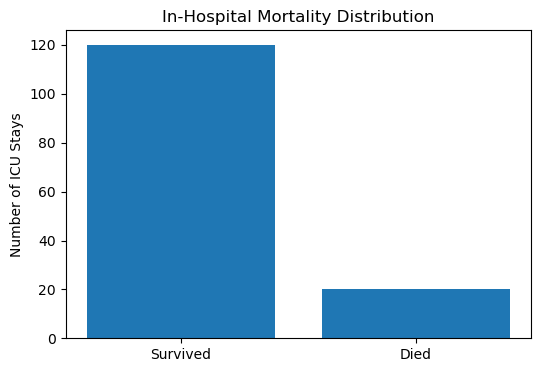

In [12]:
os.makedirs("../visuals", exist_ok=True)

target_summary_plot = icu_dataset["hospital_expire_flag"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Survived", "Died"], target_summary_plot.values)
plt.ylabel("Number of ICU Stays")
plt.title("In-Hospital Mortality Distribution")

plt.savefig("../visuals/mortality_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

### Mortality Distribution

This chart shows the distribution of the target variable, **`hospital_expire_flag`**.

In this demo dataset, there are **120 survival cases** and **20 mortality cases** across **140 ICU stays**.

This means mortality cases make up about **14.29%** of the dataset, while survival cases make up about **85.71%**.

Because mortality cases are less common than survival cases, this modeling task has **class imbalance**.

> Class imbalance matters because a model can appear accurate while still failing to identify high-risk patients.

In [13]:
icu_dataset["age_group"] = pd.cut(
    icu_dataset["age"],
    bins=[0, 30, 50, 70, 90, 120],
    labels=["0-30", "31-50", "51-70", "71-90", "90+"]
)

age_mortality = (
    icu_dataset.groupby("age_group", observed=True)["hospital_expire_flag"]
    .mean()
    .reset_index()
)

age_mortality["mortality_rate_percent"] = age_mortality["hospital_expire_flag"] * 100

age_mortality

,age_group,hospital_expire_flag,mortality_rate_percent
0,0-30,0.000000,0.000000
1,31-50,0.000000,0.000000
2,51-70,0.169014,16.901408
3,71-90,0.222222,22.222222
4,90+,0.000000,0.000000


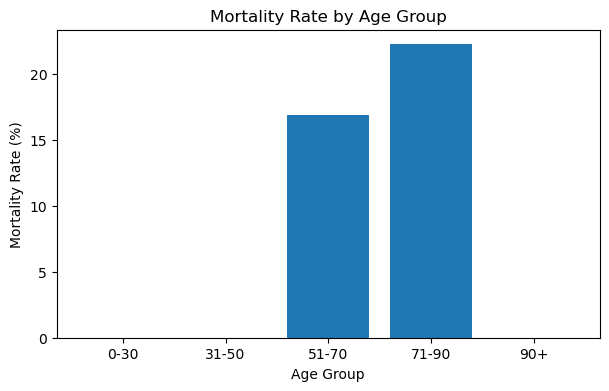

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(age_mortality["age_group"].astype(str), age_mortality["mortality_rate_percent"])
plt.xlabel("Age Group")
plt.ylabel("Mortality Rate (%)")
plt.title("Mortality Rate by Age Group")

plt.savefig("../visuals/mortality_by_age_group.png", bbox_inches="tight", dpi=300)
plt.show()

### Mortality by Age Group

This chart compares **in-hospital mortality rates** across age groups.

In this demo dataset, the mortality rate was highest among patients aged **71–90**, with a mortality rate of about **22.22%**.

The **51–70** age group also showed a higher mortality rate of about **16.90%**.

The younger age groups, **0–30** and **31–50**, showed **0% mortality** in this sample. The **90+** group also showed 0% mortality, which may be due to the small number of demo observations in that group.

Age is a common risk factor in clinical risk modeling, so this analysis helps check whether mortality patterns differ across patient age groups in the demo dataset.

> Because this is a small demo dataset, age group patterns should be interpreted carefully.

In [15]:
icu_dataset.groupby("hospital_expire_flag")["icu_los"].describe()

,count,mean,std,min,25%,50%,75%,max
hospital_expire_flag,,,,,,,,
0,120.0,3.304694,3.230205,0.155949,1.183857,2.049531,4.453328,16.180787
1,20.0,5.927487,6.285489,0.023727,0.826224,4.271302,10.436152,20.528681


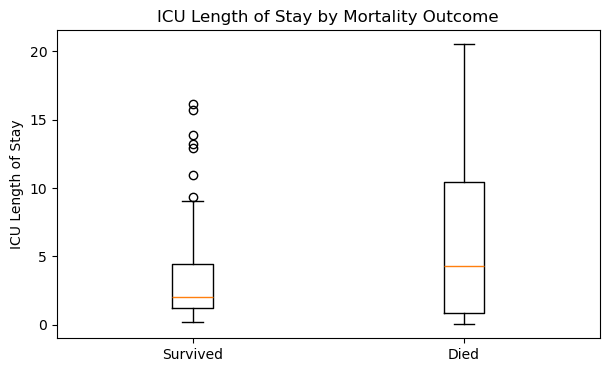

In [16]:
plt.figure(figsize=(7, 4))

survived_los = icu_dataset[icu_dataset["hospital_expire_flag"] == 0]["icu_los"].dropna()
died_los = icu_dataset[icu_dataset["hospital_expire_flag"] == 1]["icu_los"].dropna()

plt.boxplot([survived_los, died_los], tick_labels=["Survived", "Died"])
plt.ylabel("ICU Length of Stay")
plt.title("ICU Length of Stay by Mortality Outcome")

plt.savefig("../visuals/icu_los_by_mortality.png", bbox_inches="tight", dpi=300)
plt.show()

### ICU Length of Stay by Mortality Outcome

This chart compares **ICU length of stay** between patients who survived and patients who died during the hospital admission.

In this demo dataset, patients who died had a higher median ICU length of stay, about **4.27 days**, compared with about **2.05 days** for patients who survived.

The mean ICU length of stay was also higher for mortality cases, about **5.93 days**, compared with about **3.30 days** for survival cases.

This suggests that ICU length of stay may be related to patient complexity or severity in this sample.

However, ICU length of stay should be interpreted carefully because it can also be influenced by the timing of discharge or death.

> `icu_los` may be useful for baseline modeling, but it is not a direct measure of illness severity by itself.

In [17]:
admission_mortality = (
    icu_dataset.groupby("admission_type")["hospital_expire_flag"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

admission_mortality["mortality_rate_percent"] = admission_mortality["hospital_expire_flag"] * 100

admission_mortality

,admission_type,hospital_expire_flag,mortality_rate_percent
0,URGENT,0.225806,22.580645
1,DIRECT EMER.,0.200000,20.000000
2,OBSERVATION ADMIT,0.176471,17.647059
3,EW EMER.,0.134328,13.432836
4,ELECTIVE,0.000000,0.000000
5,SURGICAL SAME DAY ADMISSION,0.000000,0.000000


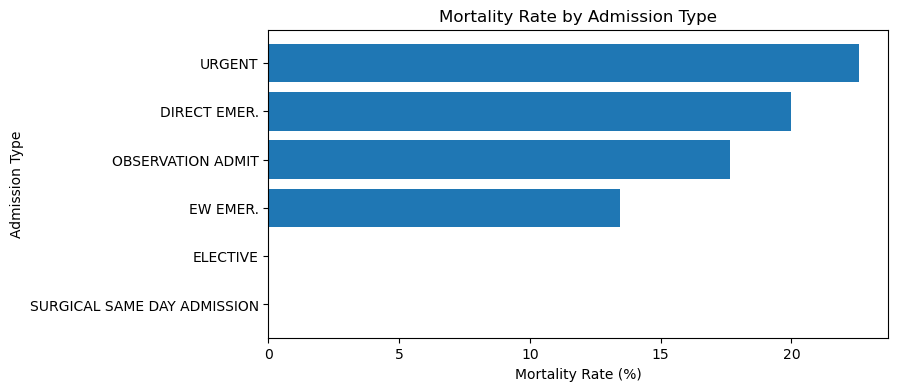

In [18]:
plt.figure(figsize=(8, 4))
plt.barh(admission_mortality["admission_type"], admission_mortality["mortality_rate_percent"])
plt.xlabel("Mortality Rate (%)")
plt.ylabel("Admission Type")
plt.title("Mortality Rate by Admission Type")
plt.gca().invert_yaxis()

plt.savefig("../visuals/mortality_by_admission_type.png", bbox_inches="tight", dpi=300)
plt.show()

### Mortality by Admission Type

This chart compares mortality rates across different hospital admission types.

In this demo dataset, **URGENT** admissions had the highest mortality rate at about **22.58%**, followed by **DIRECT EMER.** at **20.00%** and **OBSERVATION ADMIT** at about **17.65%**.

**EW EMER.** admissions showed a mortality rate of about **13.43%**.

In contrast, **ELECTIVE** and **SURGICAL SAME DAY ADMISSION** cases showed **0% mortality** in this demo sample.

This pattern suggests that admission context may provide useful information for patient risk modeling.

> Admission type should be interpreted as a contextual feature, not as a direct clinical cause of mortality.

## Feature Preparation

This section prepares the data for baseline modeling.

Version 1 uses only basic demographic, admission, and ICU stay-level features:

- **`age`**
- **`icu_los`**
- **`gender`**
- **`admission_type`**
- **`insurance`**
- **`first_careunit`**

The target variable is **`hospital_expire_flag`**.

This version does not yet include:

- Lab results from **`labevents`**
- Vital signs from **`chartevents`**
- Diagnosis codes from **`diagnoses_icd`**
- Medication records

> This keeps Version 1 focused and reproducible while leaving room for future clinical feature engineering.

### Data Leakage Note

This Version 1 model uses only demographic, admission, and ICU stay-level summary features.

Future versions should carefully limit lab results and vital signs to information available within the **first 24 hours of ICU admission**.

This is important because using information recorded after the prediction window could create **data leakage**.

Data leakage happens when a model uses information that would not realistically be available at the time of prediction.

> Preventing data leakage is especially important in healthcare risk modeling because unrealistic feature timing can make model performance look better than it would be in real clinical use.

In [19]:
model_df = icu_dataset[[
    "age",
    "icu_los",
    "gender",
    "admission_type",
    "insurance",
    "first_careunit",
    "hospital_expire_flag"
]].copy()

model_df = model_df.dropna()

print("Modeling dataset shape:", model_df.shape)

model_df.head()

Modeling dataset shape: (140, 7)


,age,icu_los,gender,admission_type,insurance,first_careunit,hospital_expire_flag
0,83,7.702512,F,SURGICAL SAME DAY ADMISSION,Other,Neuro Stepdown,0
1,63,5.452662,F,OBSERVATION ADMIT,Other,Neuro Surgical Intensive Care Unit (Neuro SICU),0
2,63,0.872685,F,SURGICAL SAME DAY ADMISSION,Other,Neuro Intermediate,0
3,91,3.766725,F,EW EMER.,Medicare,Trauma SICU (TSICU),0
4,56,1.037106,M,EW EMER.,Other,Trauma SICU (TSICU),0


In [20]:
X = model_df.drop(columns=["hospital_expire_flag"])
y = model_df["hospital_expire_flag"]

numeric_features = ["age", "icu_los"]
categorical_features = ["gender", "admission_type", "insurance", "first_careunit"]

## Baseline Model: Logistic Regression

This section builds a baseline **Logistic Regression** model.

Logistic Regression is used because the target variable is binary:

- `0` = survived
- `1` = died during the hospital admission

In this project, the model learns patterns between basic ICU patient features and the target variable **`hospital_expire_flag`**.

The purpose of this model is not to create a production-level clinical tool. Instead, it provides a simple and interpretable baseline for ICU mortality risk modeling.

> Baseline models are useful because they create a starting point for future model improvements.

Because the dataset has fewer mortality cases than survival cases, this project uses **`class_weight="balanced"`** in the Logistic Regression model.

This tells the model to give more weight to the minority class, **mortality cases**, during training.

> This adjustment helps the baseline model pay more attention to high-risk patients.

In [21]:
y.value_counts()

hospital_expire_flag
0    120
1     20
Name: count, dtype: int64

In [22]:
class_counts = y.value_counts()

if class_counts.min() >= 2:
    stratify_option = y
else:
    stratify_option = None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_option
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Train shape: (112, 6)
Test shape: (28, 6)

Train target distribution:
hospital_expire_flag
0    96
1    16
Name: count, dtype: int64

Test target distribution:
hospital_expire_flag
0    24
1     4
Name: count, dtype: int64


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Model Evaluation

Healthcare risk models should not be evaluated by accuracy alone.

In this project, the main evaluation metrics are:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Confusion Matrix**

For healthcare risk prediction, **recall** is especially important because false negatives may represent high-risk patients who were not identified by the model.

**False Negative** means:

- The patient was high-risk
- But the model predicted low-risk

> In healthcare settings, missing high-risk patients can be more serious than creating false alarms.

In [24]:
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        24
           1       0.50      1.00      0.67         4

    accuracy                           0.86        28
   macro avg       0.75      0.92      0.79        28
weighted avg       0.93      0.86      0.87        28



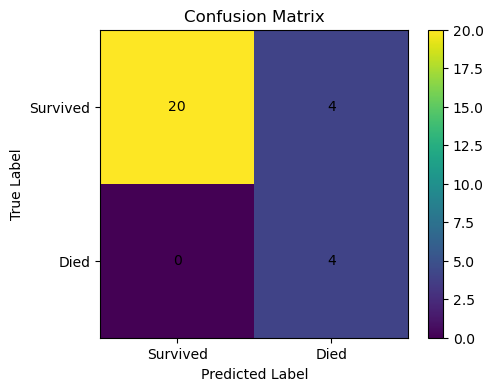

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Survived", "Died"])
plt.yticks([0, 1], ["Survived", "Died"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

plt.savefig("../visuals/confusion_matrix.png", bbox_inches="tight", dpi=300)
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows how the model classified survival and mortality cases in the test set.

In this healthcare risk setting, the most important error type is a **false negative**.

A false negative would mean that a patient who actually died during the hospital admission was predicted as lower-risk by the model.

In this test set, the balanced Logistic Regression model successfully identified all mortality cases, but it also created some false positives.

> This result reflects a common healthcare trade-off: increasing sensitivity to high-risk patients can also increase false alarms.

ROC-AUC: 0.948


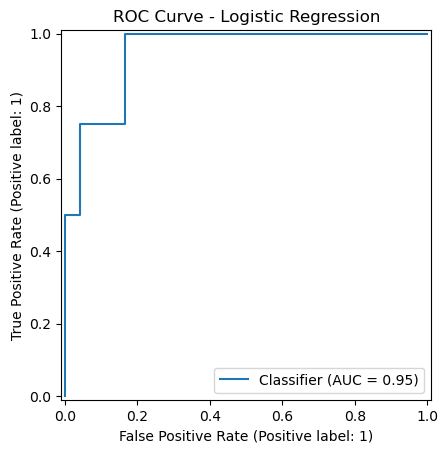

In [26]:
if len(y_test.unique()) == 2:
    roc_auc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", round(roc_auc, 3))

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC Curve - Logistic Regression")
    plt.savefig("../visuals/roc_curve.png", bbox_inches="tight", dpi=300)
    plt.show()
else:
    print("ROC-AUC cannot be calculated because only one class is present in y_test.")

### Model Performance Interpretation

The baseline Logistic Regression model achieved an accuracy of **0.86** on the test set.

For the survival class (`0`), the model achieved **precision of 1.00** and **recall of 0.83**.

For the mortality class (`1`), the model achieved **recall of 1.00**, meaning it identified all mortality cases in the test set.

However, the mortality class precision was **0.50**, meaning that some patients predicted as high-risk were false positives.

This trade-off is important in healthcare risk modeling because identifying high-risk patients may be more important than minimizing false alarms.

The model also achieved a **ROC-AUC of 0.948**, suggesting strong separation between survival and mortality cases in this small demo dataset.

> Because this project uses the MIMIC-IV Demo dataset and a small test set, these results should be interpreted as a modeling prototype rather than clinical evidence.

## Model Interpretation

To make the baseline model more interpretable, this section reviews the **Logistic Regression coefficients**.

A coefficient shows how each feature is associated with the model's predicted mortality risk.

- **Positive coefficient** = associated with higher predicted mortality risk
- **Negative coefficient** = associated with lower predicted mortality risk

This helps explain which variables the model uses most strongly when making predictions.

> In healthcare analytics, model interpretation is important because predictions should be explainable, not just accurate.

In [27]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df_sorted = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df_sorted.head(15)

,feature,coefficient,abs_coefficient
13,cat__first_careunit_Cardiac Vascular Intensive...,-1.575204,1.575204
14,cat__first_careunit_Coronary Care Unit (CCU),1.089657,1.089657
8,cat__admission_type_SURGICAL SAME DAY ADMISSION,-0.983267,0.983267
9,cat__admission_type_URGENT,0.878019,0.878019
0,num__age,0.786700,0.786700
2,cat__gender_F,-0.653925,0.653925
3,cat__gender_M,0.652741,0.652741
10,cat__insurance_Medicaid,0.633489,0.633489
19,cat__first_careunit_Surgical Intensive Care Un...,0.486212,0.486212
1,num__icu_los,0.414559,0.414559


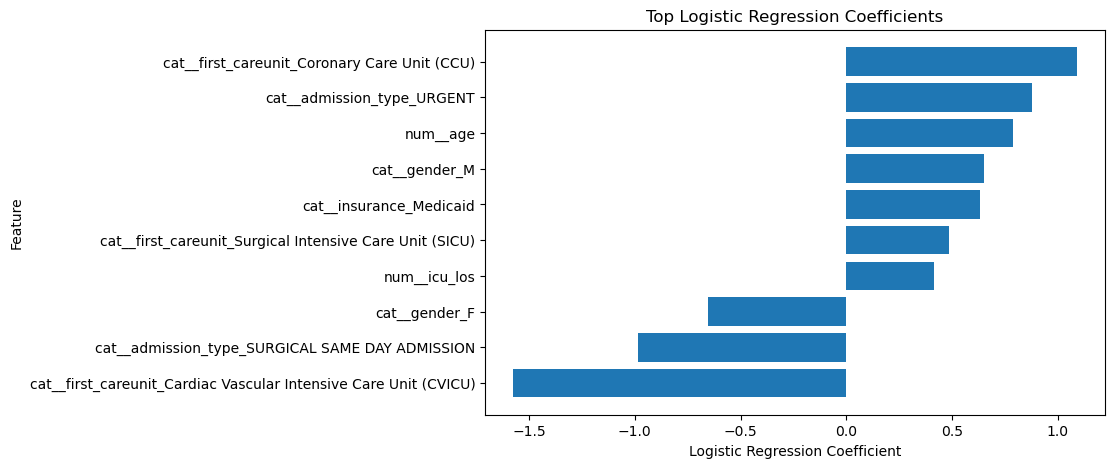

In [28]:
top_coef = coef_df_sorted.head(10).sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")

plt.savefig("../visuals/logistic_regression_coefficients.png", bbox_inches="tight", dpi=300)
plt.show()

### Coefficient Interpretation

The Logistic Regression coefficient plot shows which features had the strongest association with predicted mortality risk in the baseline model.

In this model, **age** and **ICU length of stay** had positive coefficients, meaning higher values were associated with higher predicted mortality risk.

Some admission and ICU care unit categories also appeared among the strongest model signals. For example, **URGENT admission** had a positive coefficient, while **SURGICAL SAME DAY ADMISSION** had a negative coefficient.

These patterns are reasonable for a prototype model because urgent admissions may reflect more serious patient conditions, while surgical same-day admissions may include more planned cases.

However, coefficients from this demo model should be interpreted carefully because the dataset is small and does not include richer clinical features such as labs, vital signs, diagnoses, or medications.

> These coefficients should be interpreted as model signals, not direct clinical conclusions.

## Key Findings

- This project created an **ICU stay-level dataset** by merging patient, admission, and ICU stay records from MIMIC-IV Demo.
- The final Version 1 dataset contained **140 ICU stays**, including **120 survival cases** and **20 mortality cases**.
- Mortality cases represented about **14.29%** of the dataset, showing clear **class imbalance**.
- Mortality rates were highest among patients aged **71–90** and **51–70** in this demo sample.
- Patients who died had a higher median ICU length of stay, about **4.27 days**, compared with about **2.05 days** for patients who survived.
- **URGENT** and **DIRECT EMER.** admissions showed higher mortality rates than elective or surgical same-day admissions in this sample.
- A baseline **Logistic Regression** model with **`class_weight="balanced"`** was built to predict in-hospital mortality.
- The model achieved **0.86 accuracy** and **0.948 ROC-AUC** on the test set.
- The model identified all mortality cases in the test set, but mortality precision was **0.50**, showing a trade-off between identifying high-risk patients and creating false positives.
- The model provides a **prototype risk modeling pipeline** rather than a clinical decision-making tool.

> The main value of this version is building a clean, reproducible healthcare modeling pipeline from raw EHR-style tables.

## Limitations

This project uses the **MIMIC-IV Demo** dataset, which contains a small subset of patients. Because of the small sample size, model performance should be interpreted carefully.

The test set contained only **28 ICU stays**, including **4 mortality cases**. This means evaluation metrics such as recall, precision, and ROC-AUC may change substantially with a larger dataset.

This version uses only basic demographic, admission, and ICU stay-level features. It does not yet include:

- Lab results
- Vital signs
- Diagnoses
- Medications
- First 24-hour clinical features

Because this model uses limited features, it should be viewed as a **baseline prototype** rather than a complete clinical risk model.

The model should not be interpreted as clinical evidence or used for medical decision-making.

> This project is a portfolio prototype designed to demonstrate healthcare data preparation, exploratory analysis, and baseline risk modeling.

## Future Improvements

Future versions of this project could include:

- Lab results from **`labevents`**
- Vital signs from **`chartevents`**
- First 24-hour clinical feature engineering
- Diagnosis-based comorbidity features
- Medication and procedure features
- Random Forest or Gradient Boosting models
- SHAP-based model interpretation
- More robust validation using the full MIMIC-IV dataset after completing credentialed access requirements

These improvements would make the model more clinically meaningful and closer to a full ICU risk modeling workflow.

> The next major improvement would be adding first-24-hour labs and vital signs while carefully avoiding data leakage.

## Save Project Outputs

This section saves the processed datasets and visualization files created during the project.

The processed datasets are saved locally for reproducibility, while the visual files can be used in the GitHub README.

Raw MIMIC-IV Demo data should remain excluded from the public GitHub repository.

In [29]:
processed_path = "../data/processed"
os.makedirs(processed_path, exist_ok=True)

icu_dataset.to_csv("../data/processed/icu_basic_dataset.csv", index=False)
model_df.to_csv("../data/processed/icu_modeling_dataset_v1.csv", index=False)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [30]:
print("Visual files:")
print(os.listdir("../visuals"))

print("\nProcessed data files:")
print(os.listdir("../data/processed"))

Visual files:
['confusion_matrix.png', 'mortality_distribution.png', 'icu_los_by_mortality.png', 'mortality_by_admission_type.png', 'roc_curve.png', 'logistic_regression_coefficients.png', 'mortality_by_age_group.png']

Processed data files:
['icu_modeling_dataset_v1.csv', 'icu_basic_dataset.csv']
